In [1]:
import os 
import sys
from pathlib import Path

# add parent directory to Python path
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.linalg import norm
import pandas as pd
from dgp import generate_gaussian_data
from methods import solve_independent, aggregate_results, solve_dependent
from metrics import rv_coefficient, mse
from plot_functions import plot_grid, plot_with_bands

In [2]:
from simulation_functions import run_simulation

rng = np.random.default_rng(1)

res = run_simulation(
    nsim=30,
    n=[50, 100, 150, 200],
    k=[2, 5, 7],
    sigma=[0, 0.5],
    edge_var=1,
    dgp=generate_gaussian_data,
    metrics=[mse],
    solver=solve_dependent,
    step_size=[-1, 1e-2, 1e-1, 1],
    parallel=True,
    rng=rng,
    niters=50,
)

Simulation 1 of 30


Running scenarios:   0%|          | 0/96 [00:00<?, ?it/s]


TypeError: list indices must be integers or slices, not str

In [ ]:
res_df = pd.DataFrame(res)
res_df['err_M'] = res_df['err_M'].apply(lambda x: x[0] if isinstance(x, list) else x)
res_df['err_sigma'] = res_df['err_sigma'].apply(lambda x: x[0] if isinstance(x, list) else x)

In [ ]:
out_M = res_df.drop(columns=['err_sigma'])
out_sigma = res_df.drop(columns=['err_M'])

agg_out_M = aggregate_results(out_M, y_axis='err_M', x_axis='n', factors=['step_size', 'sigma', 'k'])
agg_out_sigma = aggregate_results(out_sigma, y_axis='err_sigma', x_axis='n', factors=['step_size', 'sigma', 'k'])

In [ ]:
agg_out_M[agg_out_M['step_size'] != -1]

,n,step_size,sigma,k,err_M_mean,err_M_sem
6,50,0.01,0.0,2,2.072140,0.181379
7,50,0.01,0.0,5,5.019105,0.224236
8,50,0.01,0.0,7,7.141831,0.334681
9,50,0.01,0.5,2,1.979580,0.205196
10,50,0.01,0.5,5,4.555288,0.314662
...,...,...,...,...,...,...
91,200,1.00,0.0,5,3.915560,0.159418
92,200,1.00,0.0,7,5.372905,0.129400
93,200,1.00,0.5,2,1.347570,0.130705
94,200,1.00,0.5,5,4.054341,0.127411


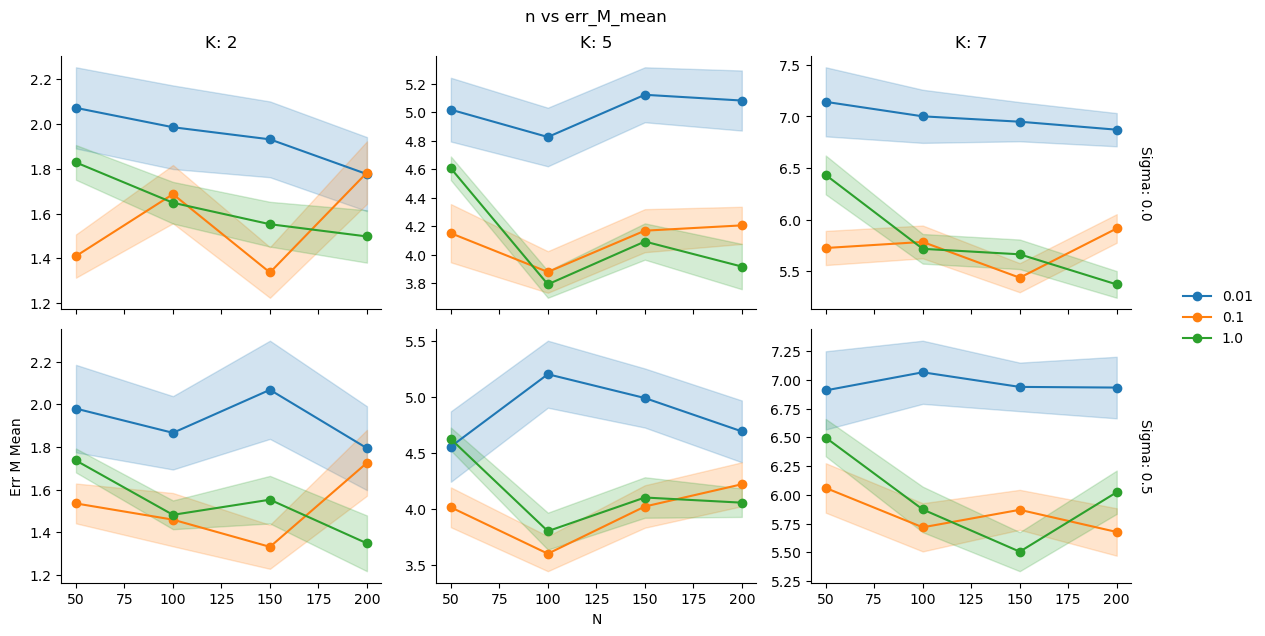

In [ ]:
plot_grid(
        grouped_stats=agg_out_M[agg_out_M['step_size'] != -1],
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='err_M_mean',
        factors=['step_size', 'k', 'sigma'],
        height=3,
        se_bands='err_M_sem',
        share_x=True,
        share_y=False
    )

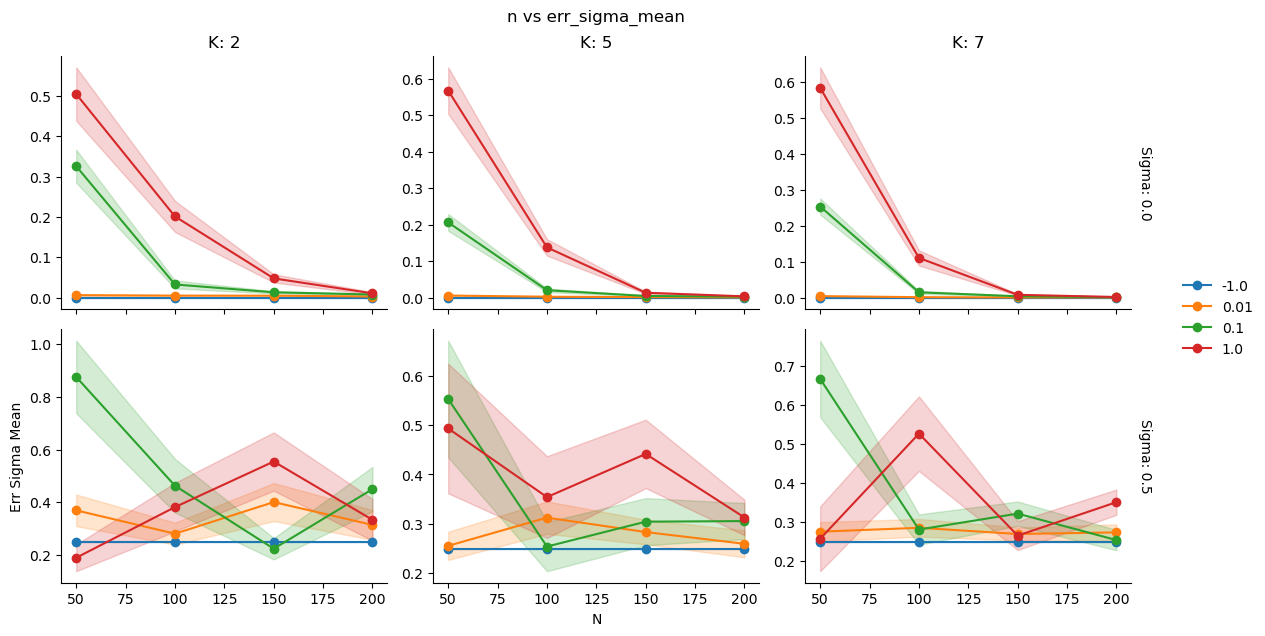

In [ ]:
plot_grid(
        grouped_stats=agg_out_sigma,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='err_sigma_mean',
        factors=['step_size', 'k', 'sigma'],
        height=3,
        se_bands='err_sigma_sem',
        share_x=True,
        share_y=False
    )